Homework 4: Excersizes
====================
ASEN 5264 Decision Making Under Uncertainty  
Cavlin Henggeler

In [1]:
using DMUStudent.HW4: HW4
# using POMDPModels: SimpleGridWorld
# using LinearAlgebra: I
using CommonRLInterface: render, actions, act!, observe, reset!, AbstractEnv, observations, terminated, clone
import POMDPTools
using SparseArrays
using Statistics: mean
using Plots

### Method 1: SARSA
Coppied from 100-SARSA.ipynb notebook

In [2]:
function sarsa_episode!(Q, env; ϵ=0.10, γ=0.99, α=0.2)
    start = time()
    
    # Epsilon-Greedy Policy
    function policy(s)
        if rand() < ϵ
            return rand(actions(env))
        else
            return argmax(a->Q[(s, a)], actions(env))
        end
    end

    
    s = observe(env)
    a = policy(s)
    r = act!(env, a)
    sp = observe(env)
    hist = [s]

    while !terminated(env)
        ap = policy(sp)

        Q[(s,a)] += α*(r + γ*Q[(sp, ap)] - Q[(s, a)])

        s = sp
        a = ap
        r = act!(env, a)
        sp = observe(env)
        push!(hist, sp)
    end

    Q[(s,a)] += α*(r - Q[(s, a)])

    return (hist=hist, Q = copy(Q), time=time()-start)
end

sarsa_episode! (generic function with 1 method)

In [3]:
function sarsa!(env; n_episodes=1000, kwargs...)
    # init s and a
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        reset!(env)
        push!(episodes, sarsa_episode!(Q, env; ϵ=max(0.1, 1-i/n_episodes), kwargs...))
    end
    
    return episodes
end

sarsa! (generic function with 1 method)

In [4]:
m = HW4.gw
env = convert(AbstractEnv, m)

DMUStudent.HW4.GridWorldEnv([10, 10], Dict{StaticArraysCore.SVector{2, Int64}, Float64}([2, 3] => 1.0, [9, 9] => 10.0, [3, 1] => -2.0, [7, 6] => -5.0, [4, 3] => -10.0), [1, 1])

In [5]:
sarsa_episodes = sarsa!(env, n_episodes=100_000, ϵ=0.15, γ=0.99, α=0.1);

In [6]:
# using Interact
# @manipulate for episode in 1:length(sarsa_episodes), step in 1:maximum(ep->length(ep.hist), sarsa_episodes)
#     ep = sarsa_episodes[episode]
#     i = min(step, length(ep.hist))
#     # render(m, (s=ep.hist[i],), color=s->maximum(map(a->ep.Q[(s,a)], actions(env))))
#     HW4.render(m, color=s->maximum(map(a->ep.Q[(s,a)], actions(env))))
# end

### Method 2: Double Q-Learning
Written based off algorithm in notes, and syntax to math notebooks

In [7]:
function Q_learning_episode!(Q, env; γ=0.99, α=0.2, ϵ=0.10)
    start = time()
    
    # Epsilon-Greedy Policy
    # a <- argmax Q(s,a) w.p/ 1-ϵ, Rand(A) w.p. ϵ
    function ϵ_greedy_policy(s)
        if rand() < ϵ
            return rand(actions(env))
        else
            return argmax(a->Q[(s, a)], actions(env))
        end
    end
    
    # First Step
    s = observe(env)    # initial state
    a = ϵ_greedy_policy(s)  # initial action
    r = act!(env, a)    
    sp = observe(env)
    hist = [s]
    
    # All other steps Steps
    while !terminated(env)
    
        # a ← argmax Q(s,a) w.p/ 1-ϵ, Rand(A) w.p. ϵ
        a = ϵ_greedy_policy(s)

        # r ← act!(env, a)
        r = act!(env, a)

        # s' ← observe(env)
        sp = observe(env)

        # Q(s,a) <- Q(s,a) + α*(r + γ*max_a' Q(s',a') - Q(s,a))
        Q[(s,a)] += α*(r + γ*maximum([Q[(sp,ap)] for ap in actions(env)]) - Q[(s,a)])
        
        # s ← s'
        s = sp
        push!(hist, sp)
    end

    # Value for terminal state
    Q[(s,a)] += α*(r - Q[(s, a)])

    return (hist=hist, Q = copy(Q), time=time()-start)
end

Q_learning_episode! (generic function with 1 method)

In [8]:
function Q_learning!(env; n_episodes=10000, kwargs...)
    # Q(s,a) <- 0 ∀ s,a
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        # println("episode: $(i)")
        reset!(env)
        push!(episodes, Q_learning_episode!(Q, env; kwargs...))
    end
    
    return episodes
end

Q_learning! (generic function with 1 method)

In [9]:
Q_episodes = Q_learning!(env, n_episodes=100_000, γ=0.99, α=0.1)

100000-element Vector{Any}:
 (hist = StaticArraysCore.SVector{2, Int64}[[1, 1], [2, 1], [1, 1], [1, 1], [1, 1], [1, 2], [2, 2], [2, 3]], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, StaticArraysCore.SVector{2, Int64}}, Float64}(([4, 2], [0, 1]) => 0.0, ([4, 10], [0, 1]) => 0.0, ([2, 9], [0, -1]) => 0.0, ([5, 7], [1, 0]) => 0.0, ([1, 1], [1, 0]) => -0.0045642189881502674, ([8, 8], [1, 0]) => 0.0, ([9, 4], [1, 0]) => 0.0, ([4, 5], [1, 0]) => 0.0, ([7, 9], [1, 0]) => 0.0, ([1, 8], [-1, 0]) => 0.0…), time = 0.013000011444091797)
 (hist = StaticArraysCore.SVector{2, Int64}[[1, 1], [1, 1], [2, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1]  …  [8, 2], [8, 3], [7, 3], [7, 4], [8, 4], [7, 4], [6, 4], [7, 4], [7, 5], [7, 6]], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, StaticArraysCore.SVector{2, Int64}}, Float64}(([4, 2], [0, 1]) => 0.0, ([4, 10], [0, 1]) => 0.0, ([2, 9], [0, -1]) => 0.0, ([5, 7], [1, 0]) => 0.0, ([1, 1], [1, 0]) => -0.0385452691550721, ([8, 8], [1, 0]

In [10]:
function double_Q_learning_episode!(Q1, Q2, env; γ=0.99, α=0.2, ϵ=0.10)
    start = time()
    
    # Epsilon-Greedy Policy
    # a <- argmax Q(s,a) w.p/ 1-ϵ, Rand(A) w.p. ϵ
    function ϵ_greedy_policy(s)
        if rand() < ϵ
            return rand(actions(env))
        else
            return argmax(a->Q1[(s, a)], actions(env))
        end
    end
    
    # First Step
    s = observe(env)    # initial state
    a = ϵ_greedy_policy(s)  # initial action
    r = act!(env, a)    
    sp = observe(env)
    hist = [s]
    
    Q_toggle = true

    # All other steps Steps
    while !terminated(env)
    
        # a ← argmax Q(s,a) w.p/ 1-ϵ, Rand(A) w.p. ϵ
        a = ϵ_greedy_policy(s)

        # r ← act!(env, a)
        r = act!(env, a)

        # s' ← observe(env)
        sp = observe(env)

        # Q1(s,a) ← Q1(s,a) + α*(r + γ*Q2(s',argmax_a' Q1(s',a')) - Q1(s,a))
        if (Q_toggle)
            ap = argmax(a->Q1[(s, a)], actions(env))
            Q1[(s,a)] += α*(r + γ*Q2[(sp,ap)] - Q1[(s,a)])
            Q_toggle = false
        else    
            ap = argmax(a->Q2[(s, a)], actions(env))
            Q2[(s,a)] += α*(r + γ*Q1[(sp,ap)] - Q2[(s,a)])
            Q_toggle = true
        end
        
        # s ← s'
        s = sp
        push!(hist, sp)
    end

    # Value for terminal state
    if (Q_toggle)
        ap = argmax(a->Q1[(s, a)], actions(env))
        Q1[(s,a)] += α*(r + γ*Q2[(sp,ap)] - Q1[(s,a)])
    else    
        ap = argmax(a->Q2[(s, a)], actions(env))
        Q2[(s,a)] += α*(r + γ*Q1[(sp,ap)] - Q2[(s,a)])
    end

    # return the last updated Q
    last_Q = Q_toggle ? Q1 : Q2
    return (hist=hist, Q = last_Q, time=time()-start)
end

double_Q_learning_episode! (generic function with 1 method)

In [11]:
function double_Q_learning!(env; n_episodes=10000, kwargs...)
    # Q(s,a) <- 0 ∀ s,a
    Q1 = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    Q2 = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    episodes = []
    
    for i in 1:n_episodes
        # println("episode: $(i)")
        reset!(env)
        push!(episodes, double_Q_learning_episode!(Q1, Q2, env; kwargs...))
    end
    
    return episodes
end

double_Q_learning! (generic function with 1 method)

In [12]:
double_Q_episodes = double_Q_learning!(env, n_episodes=100_000, γ=0.99, α=0.1)

100000-element Vector{Any}:
 (hist = StaticArraysCore.SVector{2, Int64}[[1, 1], [2, 2], [2, 1], [3, 1]], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, StaticArraysCore.SVector{2, Int64}}, Float64}(([4, 2], [0, 1]) => 6.598768179458715, ([4, 10], [0, 1]) => -0.14589732976944556, ([2, 9], [0, -1]) => -0.10988135568736561, ([5, 7], [1, 0]) => -0.11656968083598965, ([1, 1], [1, 0]) => 74.80433991457689, ([8, 8], [1, 0]) => -0.020247231927985734, ([9, 4], [1, 0]) => -0.16006769878703214, ([4, 5], [1, 0]) => -0.10462892122892103, ([7, 9], [1, 0]) => -0.10218736660944452, ([1, 8], [-1, 0]) => -0.14420431890217741…), time = 0.039999961853027344)
 (hist = StaticArraysCore.SVector{2, Int64}[[1, 1], [1, 1], [1, 1], [1, 2], [2, 2], [3, 2], [2, 2], [1, 2], [2, 2], [2, 3]], Q = Dict{Tuple{StaticArraysCore.SVector{2, Int64}, StaticArraysCore.SVector{2, Int64}}, Float64}(([4, 2], [0, 1]) => 6.598768179458715, ([4, 10], [0, 1]) => -0.14589732976944556, ([2, 9], [0, -1]) => -0.10988135568736561, ([

## Learning Curves

In [13]:
function evaluate(env, policy, n_episodes=10000, max_steps=10000, γ=1.0)
    returns = Float64[]
    for _ in 1:n_episodes
        t = 0
        r = 0.0
        reset!(env)
        s = observe(env)
        while !terminated(env)
            a = policy(s)
            r += γ^t*act!(env, a)
            s = observe(env)
            t += 1
        end
        push!(returns, r)
    end
    return returns
end

evaluate (generic function with 4 methods)

In [14]:
episodes = Dict("SARSA"=>sarsa_episodes, "Q-learning"=>Q_episodes, "Double Q-learning"=>double_Q_episodes)

Dict{String, Vector{Any}} with 3 entries:
  "Double Q-learning" => [(hist = SVector{2, Int64}[[1, 1], [2, 2], [2, 1], [3,…
  "Q-learning"        => [(hist = SVector{2, Int64}[[1, 1], [2, 1], [1, 1], [1,…
  "SARSA"             => [(hist = SVector{2, Int64}[[1, 1], [3, 1]], Q = Dict{T…

### Learning Curves by # Steps

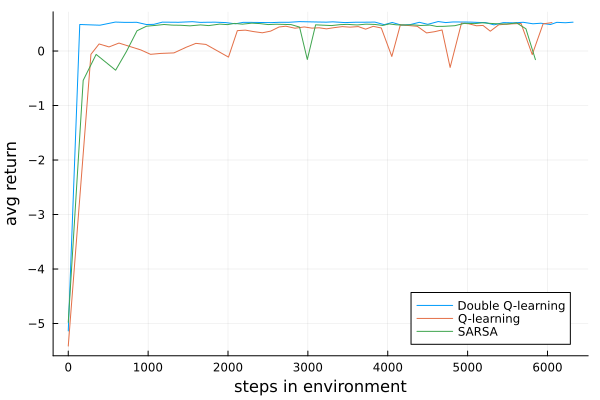

In [15]:
p = plot(xlabel="steps in environment", ylabel="avg return")
n = 20
stop = 1000
for (name, eps) in episodes
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    xs = [0]
    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
    for i in n:n:min(stop, length(eps))
        newsteps = sum(length(ep.hist) for ep in eps[i-n+1:i])
        push!(xs, last(xs) + newsteps)
        Q = eps[i].Q
        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)))))
    end    
    plot!(p, xs, ys, label=name)
end
p

### Learning Curves by Clock-time

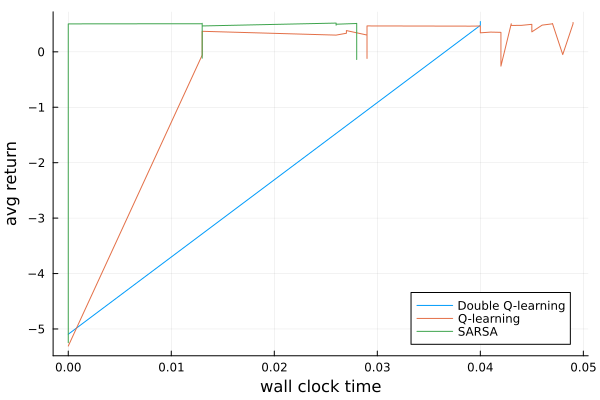

In [16]:
p = plot(xlabel="wall clock time", ylabel="avg return")
n = 20 
stop = 1000
for (name,eps) in episodes
    Q = Dict((s, a) => 0.0 for s in observations(env), a in actions(env))
    xs = [0.0]
    ys = [mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env))))]
    for i in n:n:min(stop, length(eps))
        newtime = sum(ep.time for ep in eps[i-n+1:i])
        push!(xs, last(xs) + newtime)
        Q = eps[i].Q
        push!(ys, mean(evaluate(env, s->argmax(a->Q[(s, a)], actions(env)))))
    end    
    plot!(p, xs, ys, label=name)
end
p